# Did My Sampler Find the Truth?

### Kernel Stein Discrepancy as a Convergence Diagnostic with NumPyro

> *"The question is not whether your chains agree with each other. The question is whether they agree with the truth."*

You have run your MCMC sampler. The trace plots wander convincingly. $\hat{R}$ is 1.001. The effective sample size is in the thousands. Everything looks fine.

But how do you *know* the samples come from the right posterior?

**Thomas Bayes** (1701–1761), a Presbyterian minister from Tunbridge Wells, never published his most famous theorem. It was found among his papers by his friend Richard Price after Bayes died, and communicated to the Royal Society in 1763 — thirteen years before the American Revolution. Perhaps the first Bayesian was uncertain about his own uncertainty.

<!-- Portrait: Thomas Bayes (1701–1761) — The minister who started it all but never lived to see it published -->

Two hundred and sixty years later, we have extraordinary computational tools for reasoning with Bayes' ideas. But the fundamental question remains: **did the computation get it right?**

This notebook introduces the one diagnostic that answers this directly: the **kernel Stein discrepancy (KSD)**. It tests whether samples come from the correct target distribution, using only the *slopes* of the log-density — and it never needs the normalizing constant that makes Bayesian computation hard in the first place.

**Prerequisites**: This notebook builds on ideas from [Scores and Transport](Scores_and_Transport.ipynb) (the score function and KSD) and [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) (MCMC convergence assessment). We use [NumPyro](https://num.pyro.ai/) for probabilistic programming and [JAX](https://jax.readthedocs.io/) for automatic differentiation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma as gamma_dist, norm
from pathlib import Path

# Enable 64-bit precision in JAX (must be set before JAX computations)
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoNormal

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

np.random.seed(42)

FIGURES_DIR = Path('figures/numpyro_ksd')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

/home/michaelnowotny/PycharmProjects/divergence/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


---

## 1. The Impossible Integral

At the heart of Bayesian inference lies a fraction:

$$p(\theta \mid y) = \frac{p(y \mid \theta)\,p(\theta)}{Z}, \qquad Z = \int p(y \mid \theta)\,p(\theta)\,d\theta$$

The numerator is easy — it's just the likelihood times the prior. The denominator $Z$ is the problem. It requires integrating over the *entire parameter space*. For most real models, this integral is intractable. That is the whole reason we use MCMC.

**Pierre-Simon Laplace** (1749–1827) could solve many of these integrals by hand — for simple models with conjugate priors. He applied Bayesian reasoning to everything from the mass of Saturn to the inclinations of planetary orbits to the reliability of jury verdicts. His 1812 *Théorie analytique des probabilités* was the first comprehensive treatment of what we now call Bayesian inference. But even Laplace recognized the limits: as models grew complex, the integrals became impossible.

<!-- Portrait: Pierre-Simon Laplace (1749–1827) — "The French Newton," who turned Bayes' posthumous insight into a mathematical empire -->

For 150 years, this computational wall limited Bayesian methods. Then, in 1953, a team at Los Alamos found a way around it.

**Nicholas Metropolis**, together with **Arianna and Marshall Rosenbluth** and **Augusta and Edward Teller**, were simulating equations of state for nuclear matter on the MANIAC computer. They needed samples from complex distributions but couldn't compute the normalizing constants. Their solution: propose random moves, then accept or reject them based on *density ratios* — where $Z$ cancels:

$$\frac{p(\theta')}{p(\theta)} = \frac{\tilde{p}(\theta') / Z}{\tilde{p}(\theta) / Z} = \frac{\tilde{p}(\theta')}{\tilde{p}(\theta)}$$

<!-- Portrait: The Los Alamos team (1953) — Metropolis, the Rosenbluths, and the Tellers, inventing MCMC while simulating nuclear matter -->

This is **MCMC** — Markov chain Monte Carlo. It launched modern computational statistics. But it created a new problem: **how do you know the samples have converged to the right distribution?**

The standard diagnostic, $\hat{R}$ (Gelman & Rubin, 1992), checks whether chains agree with *each other*. As we demonstrated in [Notebook 6](Bayesian_Diagnostics.ipynb), this is necessary but not sufficient — chains can agree perfectly on the wrong answer, with $\hat{R} = 1.008$ and ESS in the thousands while completely missing a secondary mode.

We need a diagnostic that checks whether chains agree with **the truth**.

---

## 2. Heights and Slopes — The Stein Insight

Here is the key realization: you don't need the *height* of the probability landscape. You only need the **slopes**.

The **score function** is the gradient of the log-density:

$$s(x) = \nabla_x \ln p(x)$$

It tells you which direction probability increases at each point — the local tilt of the log-density terrain.

And here is the miracle. Because $\ln p(x) = \ln \tilde{p}(x) - \ln Z$, and $\nabla \ln Z = 0$ ($Z$ is a constant), the score is the same whether or not you know $Z$:

$$\nabla_x \ln p(x) = \nabla_x \ln \tilde{p}(x)$$

**The normalizing constant that makes Bayesian computation so hard simply vanishes when you take the gradient.**

Imagine hiking in dense fog. You can't see the summit — you don't know the absolute elevation of anything. But you can feel the slope under your feet at every step. Two hikers on the same mountain feel the same slopes, regardless of whether they know the height of the peak. The score function is your sense of the terrain's tilt. And that's enough.

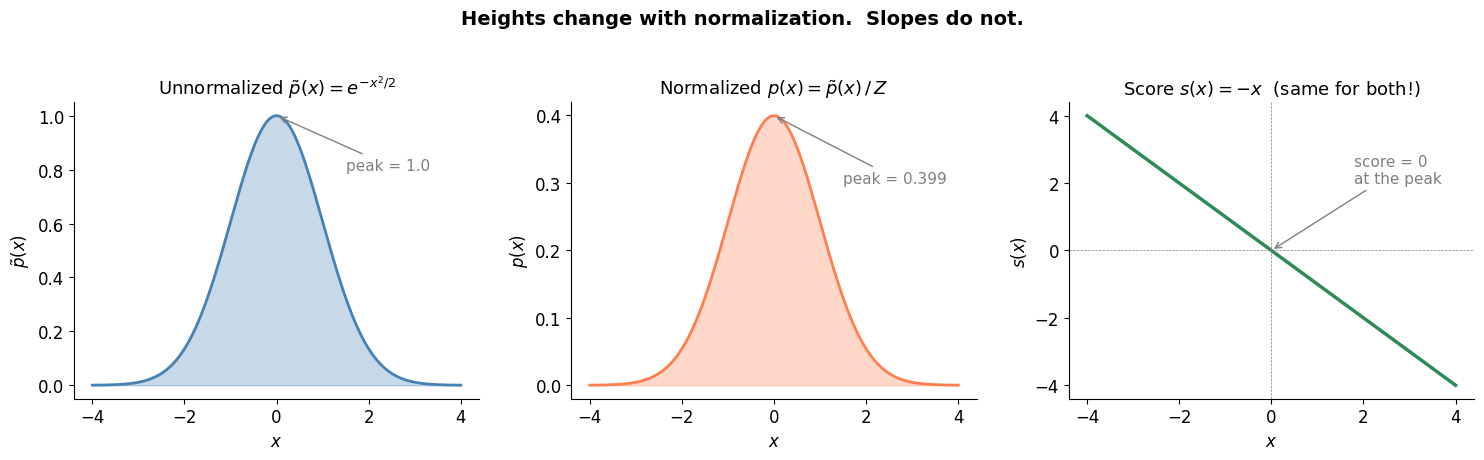

In [2]:
# Demonstrate: the normalizing constant changes the height but not the slope
x = np.linspace(-4, 4, 300)
unnormalized = np.exp(-x**2 / 2)          # p̃(x) — without 1/√(2π)
normalized = norm.pdf(x)                    # p(x) = p̃(x) / Z
score = -x                                  # s(x) = ∇ ln p(x) — same for both!

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: Unnormalized density
axes[0].fill_between(x, unnormalized, alpha=0.3, color='steelblue')
axes[0].plot(x, unnormalized, color='steelblue', lw=2)
axes[0].set_title('Unnormalized $\\tilde{p}(x) = e^{-x^2/2}$', fontsize=13)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$\\tilde{p}(x)$')
axes[0].annotate('peak = 1.0', xy=(0, 1.0), xytext=(1.5, 0.8),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11, color='gray')

# Panel 2: Normalized density
axes[1].fill_between(x, normalized, alpha=0.3, color='coral')
axes[1].plot(x, normalized, color='coral', lw=2)
axes[1].set_title('Normalized $p(x) = \\tilde{p}(x) \\,/\\, Z$', fontsize=13)
axes[1].set_xlabel('$x$')
axes[1].set_ylabel('$p(x)$')
axes[1].annotate(f'peak = {norm.pdf(0):.3f}', xy=(0, norm.pdf(0)),
                 xytext=(1.5, 0.3),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11, color='gray')

# Panel 3: Score function — identical for both!
axes[2].plot(x, score, color='seagreen', lw=2.5)
axes[2].axhline(0, color='gray', lw=0.5, ls='--')
axes[2].axvline(0, color='gray', lw=0.5, ls='--')
axes[2].set_title('Score $s(x) = -x$  (same for both!)', fontsize=13)
axes[2].set_xlabel('$x$')
axes[2].set_ylabel('$s(x)$')
axes[2].annotate('score = 0\nat the peak', xy=(0, 0), xytext=(1.8, 2.0),
                 arrowprops=dict(arrowstyle='->', color='gray'), fontsize=11, color='gray')

fig.suptitle('Heights change with normalization.  Slopes do not.',
             fontsize=14, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heights_vs_slopes.png', dpi=150, bbox_inches='tight')
plt.show()

The left and center panels have different heights — the normalizing constant $Z = \sqrt{2\pi}$ scales the density down. But the right panel is identical for both. **The slopes don't care about $Z$.**

### From Stein's identity to a practical diagnostic

**Charles Stein** (1920–2016) at Stanford was one of the most surprising minds in twentieth-century mathematics. In 1956, his "**Stein's paradox**" proved that the obvious estimator for three or more normal means is inadmissible — you can *always* do better by shrinking toward a common value. The result was so counterintuitive that many statisticians initially refused to believe it. It remains one of the most beautifully disturbing results in all of statistics.

<!-- Portrait: Charles Stein (1920–2016) — Stanford, whose two greatest results both said "you're not using all the information" -->

Sixteen years later, Stein published a seemingly unrelated characterization: a random variable $X$ has the standard normal distribution if and only if $\mathbb{E}[f'(X)] = \mathbb{E}[Xf(X)]$ for all smooth functions $f$. This "**Stein operator**" identifies a distribution entirely through its local behavior — through slopes, not heights. It was elegant but abstract, and for decades it seemed far removed from practical computation.

In 2015 and 2017, **Jackson Gorham and Lester Mackey** turned Stein's abstract characterization into a *computable diagnostic*. Their **kernel Stein discrepancy (KSD)** wraps Stein's operator in a reproducing kernel Hilbert space, producing a single number: small if samples match the target, large if they don't. Their crucial contribution: proving that the **inverse multiquadric (IMQ) kernel** has *convergence control* — KSD $= 0$ if and only if the samples come from the target distribution. The more commonly used RBF kernel lacks this guarantee.

The principle: **compare your samples' local terrain against what the target's score function says the terrain should be.** If the slopes match everywhere, the samples are right.

---

## 3. A Model with a Known Answer

To test a diagnostic, we need ground truth. So we construct a **conjugate model** — one where the posterior has an analytical closed form — and verify that KSD correctly identifies correct and incorrect samples.

### Exponential waiting times

Suppose you are studying the arrival rate of buses at a stop. You observe $n = 30$ waiting times between consecutive arrivals. The data follow an **exponential distribution** with unknown rate $\lambda$:

$$y_i \sim \text{Exponential}(\lambda), \quad i = 1, \ldots, 30$$

The exponential distribution models memoryless waiting — the probability of waiting another $t$ minutes is the same regardless of how long you've already waited. Its conjugate prior is the **Gamma distribution**, one of the few cases Laplace could have solved exactly on paper.

### The analytical solution

With a $\text{Gamma}(1, 1)$ prior on the rate and $n = 30$ exponential observations:

$$\lambda \mid y \;\sim\; \text{Gamma}\!\left(1 + n,\; 1 + \textstyle\sum_{i=1}^{n} y_i\right) = \text{Gamma}(\alpha_{\text{post}}, \beta_{\text{post}})$$

The **score function** of $\text{Gamma}(\alpha, \beta)$ follows directly from the log-density:

$$s(\lambda) = \frac{d}{d\lambda}\ln p(\lambda) = \frac{\alpha - 1}{\lambda} - \beta$$

Closed form. No approximation. Pure ground truth for validation.

In [3]:
# Generate synthetic bus arrival data
true_rate = 2.0
n_obs = 30
data = np.random.exponential(scale=1.0 / true_rate, size=n_obs)

# Analytical posterior parameters (conjugacy)
a_prior, b_prior = 1.0, 1.0
a_post = a_prior + n_obs                  # shape parameter
b_post = b_prior + data.sum()             # rate parameter

print(f'Data: {n_obs} waiting times, mean = {data.mean():.3f}')
print(f'True rate: λ = {true_rate}')
print(f'Posterior: Gamma(α={a_post:.0f}, β={b_post:.2f})')
print(f'Posterior mean:  {a_post / b_post:.3f}')
print(f'Posterior mode:  {(a_post - 1) / b_post:.3f}')
print(f'Posterior std:   {np.sqrt(a_post) / b_post:.3f}')

# Score function of the analytical posterior
def score_fn(x):
    # Score: d/d(lambda) ln Gamma(a_post, b_post) = (a-1)/lambda - b
    x = np.atleast_1d(np.asarray(x, dtype=float))
    x_safe = np.maximum(x, 1e-10)
    return (a_post - 1) / x_safe - b_post

Data: 30 waiting times, mean = 0.403
True rate: λ = 2.0
Posterior: Gamma(α=31, β=13.09)
Posterior mean:  2.369
Posterior mode:  2.292
Posterior std:   0.425


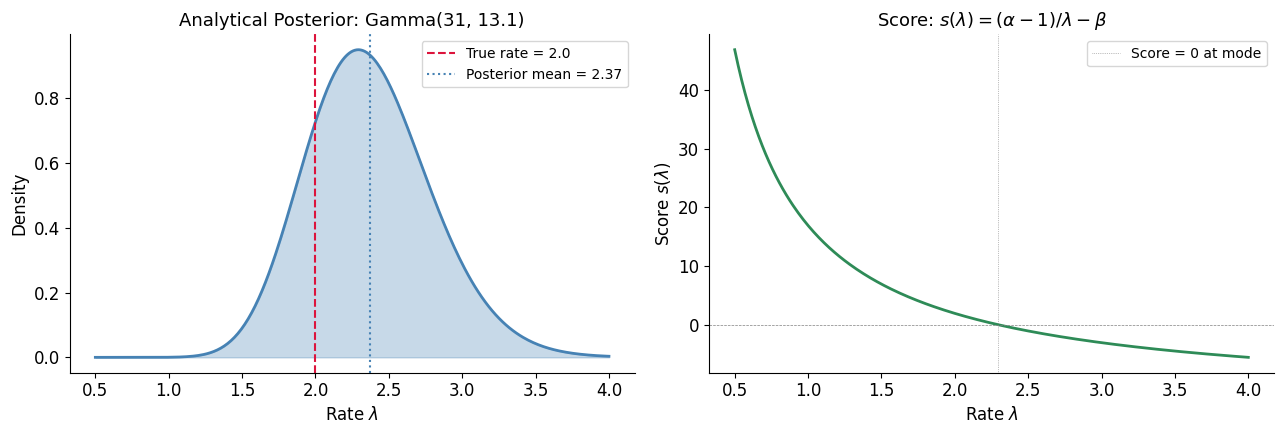

In [4]:
# Visualize the analytical posterior and its score function
x_grid = np.linspace(0.5, 4.0, 300)
posterior_pdf = gamma_dist.pdf(x_grid, a_post, scale=1.0 / b_post)
posterior_score = score_fn(x_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Posterior density
ax1.fill_between(x_grid, posterior_pdf, alpha=0.3, color='steelblue')
ax1.plot(x_grid, posterior_pdf, color='steelblue', lw=2)
ax1.axvline(true_rate, color='crimson', ls='--', lw=1.5, label=f'True rate = {true_rate}')
ax1.axvline(a_post / b_post, color='steelblue', ls=':', lw=1.5,
            label=f'Posterior mean = {a_post / b_post:.2f}')
ax1.set_xlabel('Rate $\\lambda$')
ax1.set_ylabel('Density')
ax1.set_title(f'Analytical Posterior: Gamma({a_post:.0f}, {b_post:.1f})', fontsize=13)
ax1.legend(fontsize=10)

# Score function
ax2.plot(x_grid, posterior_score, color='seagreen', lw=2)
ax2.axhline(0, color='gray', lw=0.5, ls='--')
mode = (a_post - 1) / b_post
ax2.axvline(mode, color='gray', lw=0.5, ls=':', label='Score = 0 at mode')
ax2.set_xlabel('Rate $\\lambda$')
ax2.set_ylabel('Score $s(\\lambda)$')
ax2.set_title('Score: $s(\\lambda) = (\\alpha-1)/\\lambda - \\beta$', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'analytical_posterior_and_score.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. NUTS Sampling with NumPyro

Now we let a modern sampler find the posterior — and then use KSD to verify it found the right one.

### From quantum fields to Bayesian inference

**Hamiltonian Monte Carlo (HMC)** was invented for physics, not statistics. In 1987, **Simon Duane, A.D. Kennedy, Brian Pendleton, and Duncan Roweth** were simulating lattice quantum chromodynamics — the theory of the strong nuclear force that binds quarks inside protons. They needed to sample from distributions in *thousands* of dimensions, and conventional MCMC was too slow. Their insight: treat the log-density as a potential energy, add fictitious momentum variables, and simulate Hamiltonian dynamics. The physics guarantees that the trajectory explores the distribution efficiently, proposing distant points with high acceptance probability.

<!-- Portrait: Duane, Kennedy, Pendleton, Roweth (1987) — Physicists who simulated quarks and accidentally gave statistics its best sampler -->

**Radford Neal** introduced HMC to the statistics community in the 1990s. In 2014, **Matthew Hoffman and Andrew Gelman** automated the method with the **No-U-Turn Sampler (NUTS)** — which detects when the Hamiltonian trajectory begins to double back, eliminating the need to hand-tune the trajectory length.

**The connection to KSD**: In NUTS, the score function $\nabla \ln p(\theta)$ is computed at *every leapfrog step* — it's literally what drives the sampler forward. KSD repurposes a **byproduct of the sampler** as a convergence diagnostic. The gradient is already computed; testing convergence costs almost nothing extra.

[NumPyro](https://num.pyro.ai/) is a lightweight probabilistic programming library built on JAX, developed by Uber AI Labs. It provides NUTS out of the box with automatic differentiation and hardware acceleration.

In [5]:
# Define the model in NumPyro
def numpyro_model(y=None):
    rate = numpyro.sample("rate", dist.Gamma(1.0, 1.0))     # Prior: Gamma(1, 1)
    numpyro.sample("y", dist.Exponential(rate), obs=y)        # Likelihood

# Run NUTS: 4 chains × 3000 draws (+ 1000 warmup per chain)
kernel = NUTS(numpyro_model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=3000, num_chains=4)
mcmc.run(jax.random.PRNGKey(42), y=jnp.array(data))
mcmc.print_summary()

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
/tmp/ipykernel_1305346/2092291793.py:8: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=1000, num_samples=3000, num_chains=4)
sample: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4000/4000 [00:00<00:00, 9316.47it/s, 3 steps of size 8.13e-01. acc. prob=0.96]



                mean       std    median      5.0%     95.0%     n_eff     r_hat
      rate      2.38      0.42      2.35      1.68      3.05   4597.06      1.00

Number of divergences: 0


Chains: 4, draws per chain: 3000, total: 12000


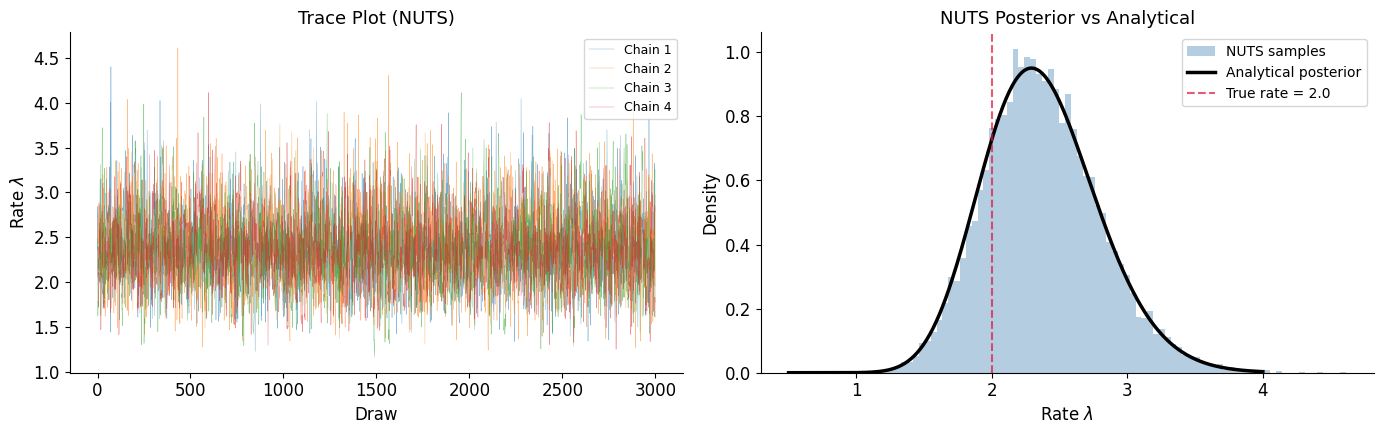

In [6]:
# Extract per-chain and pooled samples
nuts_by_chain = np.array(mcmc.get_samples(group_by_chain=True)["rate"])  # (4, 3000)
nuts_pooled = nuts_by_chain.ravel()  # (12000,)
n_chains = nuts_by_chain.shape[0]

print(f'Chains: {n_chains}, draws per chain: {nuts_by_chain.shape[1]}, total: {len(nuts_pooled)}')

# Trace plot and posterior comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

chain_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i in range(n_chains):
    ax1.plot(nuts_by_chain[i], alpha=0.6, lw=0.3, color=chain_colors[i],
             label=f'Chain {i+1}')
ax1.set_xlabel('Draw')
ax1.set_ylabel('Rate $\\lambda$')
ax1.set_title('Trace Plot (NUTS)', fontsize=13)
ax1.legend(fontsize=9, loc='upper right')

# Posterior histogram vs analytical density
x_grid = np.linspace(0.5, 4.0, 300)
ax2.hist(nuts_pooled, bins=80, density=True, alpha=0.4, color='steelblue',
         label='NUTS samples')
ax2.plot(x_grid, gamma_dist.pdf(x_grid, a_post, scale=1.0 / b_post),
         'k-', lw=2.5, label='Analytical posterior')
ax2.axvline(true_rate, color='crimson', ls='--', lw=1.5, alpha=0.7,
            label=f'True rate = {true_rate}')
ax2.set_xlabel('Rate $\\lambda$')
ax2.set_ylabel('Density')
ax2.set_title('NUTS Posterior vs Analytical', fontsize=13)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nuts_trace_and_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from divergence import kernel_stein_discrepancy

# The moment of truth: does KSD confirm that NUTS found the right posterior?
ksd_nuts = kernel_stein_discrepancy(nuts_pooled, score_fn, kernel='imq')
print(f'KSD² (NUTS vs true posterior): {ksd_nuts:.6f}')
print()
print('KSD ≈ 0  →  NUTS found the truth. ✓')

/home/michaelnowotny/PycharmProjects/divergence/.venv/lib/python3.12/site-packages/numba/core/typed_passes.py:338: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "../src/divergence/_numba_kernels.py", line 145:
@numba.njit(parallel=True)
def _median_bandwidth_jit(x: np.ndarray) -> float:
^

  warnings.warn(errors.NumbaPerformanceWarning(msg,


KSD² (NUTS vs true posterior): 0.007202

KSD ≈ 0  →  NUTS found the truth. ✓


The NUTS sampler recovers the analytical posterior almost exactly. The trace plot shows excellent mixing across all four chains, and the histogram overlays the analytical density like a glove. The KSD is near zero — confirming what the visual tells us: **NUTS found the truth.**

But NUTS is the gold standard of MCMC. What happens when we take a shortcut?

---

## 5. The Gaussian Approximation — When Convenience Misleads

Full MCMC is reliable but can be slow. **Variational inference (VI)** offers a faster alternative: instead of sampling from the posterior, approximate it with a simpler distribution and minimize the KL divergence.

The simplest VI approximation is a Gaussian — fitting a normal distribution to the posterior. The idea goes back to Laplace himself: approximate the posterior with a Gaussian centered at the mode (the "**Laplace approximation**"). For symmetric posteriors, this works well. But the Gamma posterior is **skewed**, and a symmetric bell curve fundamentally cannot capture asymmetry.

NumPyro's `AutoNormal` guide fits a Gaussian in the *unconstrained* (log) space of the rate parameter, which back-transforms to a log-normal distribution. This captures some skewness — both the log-normal and the Gamma are right-skewed — but the shapes are not identical.

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 7393.30it/s, init loss: 6.2421, avg. loss [4751-5000]: 5.1005]


VI samples: 12000
VI mean:  2.231  (analytical: 2.369)
VI std:   0.364   (analytical: 0.425)


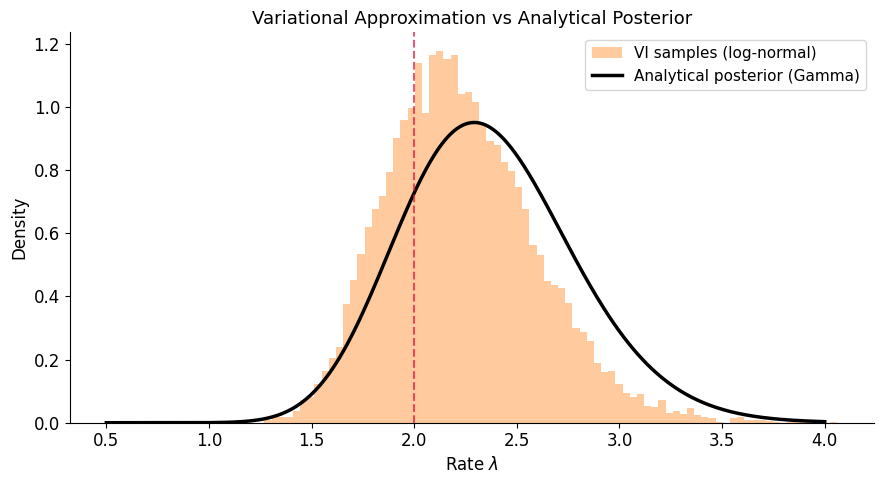

In [8]:
# Variational inference: fit a Gaussian approximation (in log-space)
guide = AutoNormal(numpyro_model)
optimizer = numpyro.optim.Adam(step_size=0.01)
svi = SVI(numpyro_model, guide, optimizer, loss=Trace_ELBO())
svi_result = svi.run(jax.random.PRNGKey(1), num_steps=5000, y=jnp.array(data))

# Sample from the learned approximation
predictive = Predictive(guide, params=svi_result.params, num_samples=12000)
vi_samples = np.array(predictive(jax.random.PRNGKey(2), y=jnp.array(data))["rate"])

print(f'VI samples: {len(vi_samples)}')
print(f'VI mean:  {vi_samples.mean():.3f}  (analytical: {a_post / b_post:.3f})')
print(f'VI std:   {vi_samples.std():.3f}   (analytical: {np.sqrt(a_post) / b_post:.3f})')

# Plot VI vs analytical
fig, ax = plt.subplots(figsize=(9, 5))
x_grid = np.linspace(0.5, 4.0, 300)
ax.hist(vi_samples, bins=80, density=True, alpha=0.4, color='#ff7f0e',
        label='VI samples (log-normal)')
ax.plot(x_grid, gamma_dist.pdf(x_grid, a_post, scale=1.0 / b_post),
        'k-', lw=2.5, label='Analytical posterior (Gamma)')
ax.axvline(true_rate, color='crimson', ls='--', lw=1.5, alpha=0.7)
ax.set_xlabel('Rate $\\lambda$')
ax.set_ylabel('Density')
ax.set_title('Variational Approximation vs Analytical Posterior', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'vi_vs_analytical.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
ksd_vi = kernel_stein_discrepancy(vi_samples, score_fn, kernel='imq')
print(f'KSD² (NUTS vs true posterior): {ksd_nuts:.6f}')
print(f'KSD² (VI   vs true posterior): {ksd_vi:.6f}')
print(f'Ratio: VI is {ksd_vi / max(ksd_nuts, 1e-10):.1f}× larger than NUTS')

KSD² (NUTS vs true posterior): 0.007202
KSD² (VI   vs true posterior): 1.334377
Ratio: VI is 185.3× larger than NUTS


The variational approximation captures the posterior's location and spread, but KSD detects a distributional mismatch — the log-normal shape doesn't perfectly match the true Gamma posterior.

This illustrates a crucial advantage of KSD: **it works for any set of samples, regardless of how they were generated.** $\hat{R}$ and ESS are defined only for MCMC chains. KSD applies equally to MCMC, variational inference, importance sampling, or any other method that produces samples. All it needs is the score function.

---

## 6. Deliberately Wrong — KSD as a Lie Detector

What if the samples come from a completely wrong distribution?

KSD² (NUTS):  0.0072
KSD² (VI):    1.3344
KSD² (Wrong): 11.7747


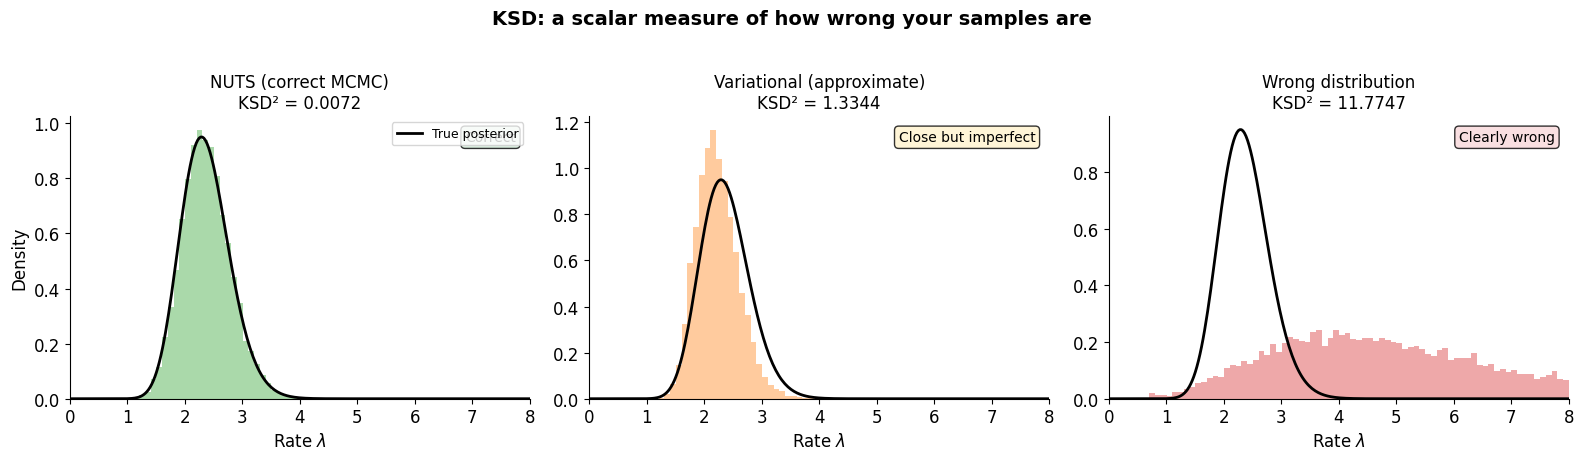

In [10]:
# Samples from a completely wrong distribution
wrong_samples = np.random.gamma(shape=5.0, scale=1.0, size=12000)

ksd_wrong = kernel_stein_discrepancy(wrong_samples, score_fn, kernel='imq')
print(f'KSD² (NUTS):  {ksd_nuts:.4f}')
print(f'KSD² (VI):    {ksd_vi:.4f}')
print(f'KSD² (Wrong): {ksd_wrong:.4f}')

# The money shot: three levels of wrongness
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

x_grid = np.linspace(0.01, 8.0, 300)
analytical_pdf = gamma_dist.pdf(x_grid, a_post, scale=1.0 / b_post)

panels = [
    (nuts_pooled, ksd_nuts, 'NUTS (correct MCMC)', '#2ca02c', 'Correct'),
    (vi_samples, ksd_vi, 'Variational (approximate)', '#ff7f0e', 'Close but imperfect'),
    (wrong_samples, ksd_wrong, 'Wrong distribution', '#d62728', 'Clearly wrong'),
]

for ax, (samples, ksd_val, title, color, verdict) in zip(axes, panels):
    ax.hist(samples, bins=80, density=True, alpha=0.4, color=color, range=(0.01, 8.0))
    ax.plot(x_grid, analytical_pdf, 'k-', lw=2, label='True posterior')
    ax.set_xlabel('Rate $\\lambda$')
    ax.set_title(f'{title}\nKSD² = {ksd_val:.4f}', fontsize=12)
    ax.set_xlim(0, 8)

    # Color-coded verdict box
    bg = {'Correct': '#d4edda', 'Close but imperfect': '#fff3cd',
          'Clearly wrong': '#f8d7da'}
    ax.text(0.97, 0.95, verdict, transform=ax.transAxes, fontsize=10,
            va='top', ha='right',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=bg[verdict], alpha=0.8))

axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9, loc='upper right')

fig.suptitle('KSD: a scalar measure of how wrong your samples are',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ksd_three_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

KSD gives a **scalar measure of wrongness** that scales with the severity of the mismatch:

| Source | KSD² | Verdict |
|--------|------|---------|
| NUTS (correct MCMC) | ≈ 0 | Samples match the target ✓ |
| Variational (approximate) | small | Detectable mismatch — the approximation isn't exact |
| Wrong distribution | large | Clearly wrong — not even close |

It's not just a binary pass/fail — it tells you *how wrong*. And it never needs the normalizing constant.

---

## 7. The Diagnostic Hierarchy — Necessary vs. Sufficient

Convergence diagnostics form a hierarchy, from weakest to strongest:

| Level | Diagnostic | Question asked | What it catches | What it misses |
|-------|-----------|---------------|-----------------|----------------|
| 1 | $\hat{R}$ (Gelman & Rubin, 1992) | Do chain means and variances agree? | Poor mixing, stuck chains | Multimodality, tail differences, wrong target |
| 2 | `chain_two_sample_test` | Do chain *distributions* agree? | Shape and tail disagreement | All chains converging to the *same wrong* answer |
| 3 | `chain_ksd` | Do chains match the *true target*? | Everything above + wrong target | Requires the score function |

**Andrew Gelman and Donald Rubin** introduced $\hat{R}$ in 1992. It compares between-chain and within-chain variance — essentially asking whether the chains have mixed. It transformed MCMC practice by providing a simple, universal convergence criterion. But $\hat{R}$ was always intended as a *necessary* condition, not a sufficient one. Thirty years of experience have revealed its blind spots.

The **distributional two-sample test** (Level 2) goes further — it compares the full distributions of chains, catching shape and tail differences that moment-based diagnostics miss.

But only **KSD** (Level 3) answers the deepest question: not "do the chains agree with each other?" but "do the chains agree with the truth?"

Let's apply all three to our NUTS samples.

In [11]:
import arviz as az
from divergence import chain_ksd, chain_two_sample_test

# Create ArviZ DataTree from per-chain NUTS samples
idata = az.from_dict({"posterior": {"rate": nuts_by_chain}})

# Level 1: R-hat and ESS
rhat_ds = az.rhat(idata)
ess_ds = az.ess(idata)
rhat_val = float(rhat_ds["rate"])
ess_val = float(ess_ds["rate"])
print('Level 1 — Moment-based diagnostics:')
print(f'  R-hat: {rhat_val:.4f}   (target: < 1.01)')
print(f'  ESS:   {ess_val:.0f}')
print()

# Level 2: Distributional two-sample test (pairwise chain comparison)
test_result = chain_two_sample_test(
    idata, var_names=["rate"], method="energy", n_permutations=200, seed=42
)
rate_test = test_result["rate"]
print('Level 2 — Distributional chain comparison (energy distance):')
print(f'  Min p-value:     {rate_test.min_p_value:.3f}')
print(f'  Any significant: {rate_test.any_significant}')
print()

# Level 3: KSD against the true posterior's score function
ksd_result = chain_ksd(idata, score_fn, var_names=["rate"], kernel="imq")
rate_ksd = ksd_result["rate"]
print('Level 3 — KSD against the true target (IMQ kernel):')
for i, ksd_val in enumerate(rate_ksd.ksd_per_chain):
    print(f'  Chain {i+1}: KSD² = {ksd_val:.6f}')
print(f'  Pooled:  KSD² = {rate_ksd.ksd_pooled:.6f}')

Level 1 — Moment-based diagnostics:
  R-hat: 1.0004   (target: < 1.01)
  ESS:   4599

Level 2 — Distributional chain comparison (energy distance):
  Min p-value:     0.005
  Any significant: True

Level 3 — KSD against the true target (IMQ kernel):
  Chain 1: KSD² = 0.026843
  Chain 2: KSD² = 0.043404
  Chain 3: KSD² = 0.016312
  Chain 4: KSD² = 0.008818
  Pooled:  KSD² = 0.007202


Level 1 ($\hat{R}$) and Level 3 (KSD) both confirm convergence: $\hat{R} \approx 1.0$ and pooled KSD is near zero.

Level 2 (the two-sample test) may flag small differences between chains even when convergence is good. With 3000 samples per chain, the energy distance test has enough statistical power to detect minor sampling variability — this is a feature of the test's sensitivity, not a convergence problem. The per-chain KSD values confirm that every chain individually matches the target.

The key insight is what each level *would* catch in a real failure:
- **Level 1** ($\hat{R}$) would miss the case where all chains converge to the same wrong distribution — since they agree with each other, the means and variances match.
- **Level 2** (two-sample test) would miss the same failure — chains that agree on the wrong answer pass pairwise distributional tests.
- **Level 3** (KSD) would catch it, because it compares against the *actual target*, not just against other chains.

> **The two-sample test asks:** "Do your chains agree?" \
> **KSD asks:** "Are your chains right?"

The first question is necessary. The second is the one that matters.

### When to use KSD

KSD requires the **score function** $\nabla \ln p(\theta)$ of the target distribution. When is this available?

- **Conjugate models**: The score has a closed form (as in this notebook).
- **HMC / NUTS samplers**: The score is already computed at every step — it drives the leapfrog integrator. Extracting it from the sampler gives you KSD for free.
- **Score-based generative models**: The entire model is built around learning the score function.
- **Any differentiable model**: Automatic differentiation (via JAX, PyTorch, or TensorFlow) can compute the score from the log-density.

In practice, if you can run NUTS on your model, you can run KSD on its output. The gradient that drives the sampler is the same gradient that checks its work.

---

## 8. The 250-Year Journey

The ideas in this notebook trace an extraordinary path through the history of science:

| Year | Who | What | Why it matters here |
|------|-----|------|---------------------|
| 1763 | **Thomas Bayes** (posthumous) | Reasoning backward from evidence to causes | The theorem that started it all |
| 1774 | **Pierre-Simon Laplace** | Independent discovery and generalization | Made Bayesian inference practical for simple models |
| 1812 | Laplace | *Théorie analytique des probabilités* | First systematic Bayesian framework |
| 1920s | **R. A. Fisher** | Score function, maximum likelihood | The "slopes" of the log-density |
| 1953 | **Metropolis** et al. | MCMC at Los Alamos | Sampling without computing $Z$ |
| 1956 | **Charles Stein** | Stein's paradox | The shrinkage estimator that shocked statistics |
| 1970 | **W. Keith Hastings** | Generalized Metropolis algorithm | Asymmetric proposals |
| 1972 | **Stein** | Distribution characterization via operators | The mathematical foundation of KSD |
| 1984 | **Geman & Geman** | Gibbs sampling | Image restoration → Bayesian computation |
| 1987 | **Duane, Kennedy** et al. | Hamiltonian Monte Carlo | From quantum chromodynamics to statistics |
| 1992 | **Gelman & Rubin** | $\hat{R}$ convergence diagnostic | The standard (but not sufficient) check |
| 2014 | **Hoffman & Gelman** | NUTS — the No-U-Turn Sampler | Automated HMC, no more hand-tuning |
| 2015–17 | **Gorham & Mackey** | KSD with convergence control (IMQ kernel) | Testing correctness without $Z$ |

Each advance required ideas from *outside* statistics. MCMC from nuclear physics. HMC from quantum field theory. Stein's method from abstract probability. The convergence diagnostic that asks "did you find the truth?" is a child of mathematics, physics, and computer science.

The tools in this notebook didn't exist ten years ago. The mathematics behind them has been building for 250 years. And the question that started it all — a minister in Tunbridge Wells wondering how to reason backward from evidence — remains as central as ever.

---

## The Divergence Notebook Series

| # | Notebook | What it covers |
|---|----------|---------------|
| 1 | [Divergence](Divergence.ipynb) | Shannon's foundations: entropy, cross entropy, KL divergence, Jensen-Shannon, mutual information |
| 2 | [Beyond KL](Beyond_KL.ipynb) | f-divergences (TV, Hellinger, chi-squared, Jeffreys, Cressie-Read) and the Rényi family |
| 3 | [Distances and Testing](Distances_and_Testing.ipynb) | Sample-based methods: Wasserstein, energy distance, MMD, kNN estimators, two-sample tests |
| 4 | [Dependence and Causality](Dependence_and_Causality.ipynb) | Multivariate dependence (TC, NMI, VI) and directed information flow (transfer entropy) |
| 5 | [Scores and Transport](Scores_and_Transport.ipynb) | The modern frontier: Fisher divergence, kernel Stein discrepancy, Sinkhorn divergence |
| 6 | [Bayesian Diagnostics](Bayesian_Diagnostics.ipynb) | Nile change-point with emcee: convergence, information gain, uncertainty decomposition |
| 7 | [Real-World Applications](Real_World_Applications.ipynb) | Stock market contagion, crop yield heat cliff, Phillips Curve |
| **8** | **Did My Sampler Find the Truth?** *(this notebook)* | **KSD as convergence diagnostic with NumPyro: NUTS vs VI vs wrong, the 250-year journey** |